# GFC 2007–2009: overall headline sentiment (RavenBERT)

Overall tone of the RavenPack headline flow around the Global Financial Crisis, from the RavenBERT
`headline_sentiment` artifact (the model's predicted distribution over 41 ordinal classes on
s ∈ [−1, 1], per headline). This is **pure sentiment over all headlines**: it is not yet
conditioned on narratives. The sentiment × narrative view comes from the sentiment-bucket
`narrative_daily` runs once they are scored.

The notebook reads the datalake only. Monthly daily aggregates are cached next to it in
`.cache/` (git-ignored by the `.*cache/` rule; `daily_sentiment.py` builds them, ~2 s per month).

| quantity | definition |
|---|---|
| SENT | ordinal mean of a headline's predicted distribution (rule `mean`, as the scoring's bucket runs) |
| CONF | 1 − standard deviation of that distribution |
| share negative / positive | share of headlines with SENT ≤ −1/3 / SENT ≥ 1/3 (the bucket thresholds) |
| NET_TONE | share positive − share negative |
| ESS | RavenPack's own EVENT_SENTIMENT_SCORE (entity-level, averaged per story, ~30% of stories) |
| Q_00..Q_40 | the period's mean predicted distribution |

Days are UTC calendar days (weekends included, where the flow is smaller and more negative);
weeks run Monday–Sunday and are labelled by their Monday.

In [2]:
import os
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import TwoSlopeNorm
from dotenv import find_dotenv, load_dotenv

from datalake import DatalakeIndex
from nlp.sentiment.base import GRID
from daily_sentiment import NEG_MAX, POS_MIN, load_daily, locate, summarise

load_dotenv(find_dotenv(usecwd=True))
pl.Config.set_tbl_rows(40); pl.Config.set_tbl_width_chars(220)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.constrained_layout.use": True})

# ---- data -----------------------------------------------------------------------------
SOURCE = "ravenbert"            # headline_sentiment producer
SENTIMENT_ID = None             # None = the latest complete artifact of SOURCE
CACHE_DIR = Path(".cache")
ROLL = 20                       # days, rolling mean on daily series

# ---- study windows --------------------------------------------------------------------
LOAD = (date(2004, 7, 1), date(2010, 12, 31))       # everything read (baseline included)
VIEW = (date(2005, 1, 1), date(2010, 12, 31))
BASELINE = (date(2004, 7, 1), date(2007, 6, 30))   # pre-crisis reference for z-scores
CRISIS = (date(2007, 8, 1), date(2009, 6, 30))     # shaded band

EVENTS = {
    "BNP funds frozen": date(2007, 8, 9),
    "Northern Rock": date(2007, 9, 14),
    "Bear Stearns": date(2008, 3, 14),
    "GSE conservatorship": date(2008, 9, 7),
    "Lehman": date(2008, 9, 15),
    "TARP signed": date(2008, 10, 3),
    "Coordinated cut": date(2008, 10, 8),
    "NBER recession call": date(2008, 12, 1),
    "Equity trough": date(2009, 3, 9),
    "SCAP results": date(2009, 5, 7),
}
KEY_EVENTS = ("BNP funds frozen", "Bear Stearns", "Lehman", "Equity trough")


def shade_events(ax, which=KEY_EVENTS, labels=True):
    ymax = ax.get_ylim()[1]
    ax.axvspan(*CRISIS, color="tab:red", alpha=0.06, zorder=0)
    for name in which:
        d = EVENTS[name]
        ax.axvline(d, color="0.35", lw=0.8, ls="--", zorder=0)
        if labels:
            ax.text(d, ymax, f" {name}", rotation=90, va="top", ha="right", fontsize=7, color="0.3")


def date_axis(ax, lo=VIEW[0], hi=VIEW[1]):
    ax.set_xlim(lo, hi)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

## 1. Data

Sums per (UTC day, news type) are read (or built and cached) month by month, then combined:
`daily` over all news types, `weekly` by Monday-labelled week.

In [3]:
dl = DatalakeIndex(os.environ["DATALAKE_ROOT"], create=False)
SRC = locate(dl, SOURCE, SENTIMENT_ID)
print("sentiment:", SRC.sentiment_id)
print("headlines:", SRC.headlines_id)

sums = load_daily(SRC, *LOAD, CACHE_DIR, neg_max=NEG_MAX, pos_min=POS_MIN)
sums = sums.with_columns(pl.col("DATE").dt.truncate("1w").alias("WEEK"))
daily = summarise(sums, ["DATE"])
weekly = summarise(sums, ["WEEK"])
print(f"{daily.height:,} days, {weekly.height} weeks, {int(daily['N'].sum()):,} headlines; "
      f"{daily['DATE'].min()} .. {daily['DATE'].max()}")
print(f"share of headlines with a model output: {daily['N_SCORED'].sum() / daily['N'].sum():.4%}")

sentiment: headline_sentiment__ravenbert-sentiment-2.1__v0.2.0__params0f2600a3__20260928
headlines: ravenpack_headlines__v0.1.0__end_year2025_start_year2000__20260911
2,375 days, 340 weeks, 74,956,703 headlines; 2004-07-01 .. 2010-12-31
share of headlines with a model output: 100.0000%


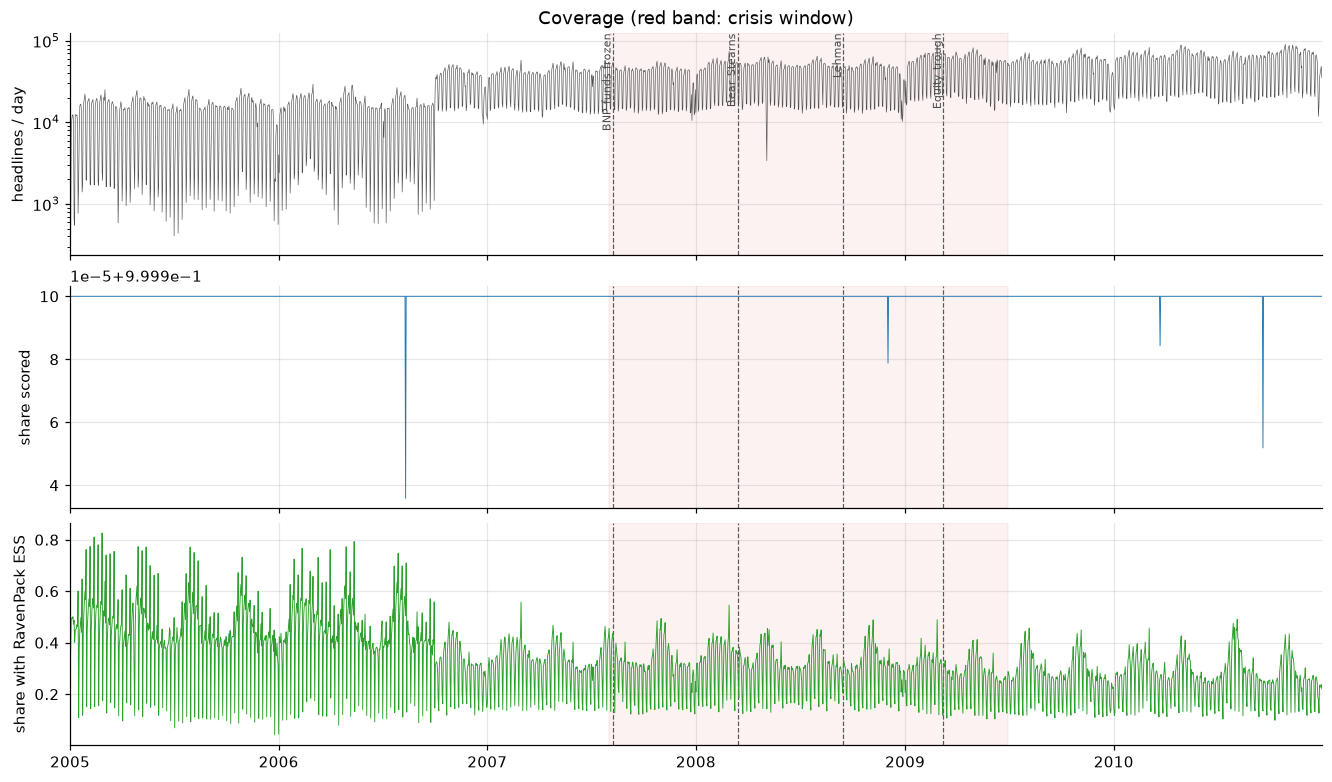

In [4]:
v = daily.filter(pl.col("DATE").is_between(*VIEW))
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(v["DATE"], v["N"], lw=0.4, color="0.3"); axes[0].set_yscale("log")
axes[0].set_ylabel("headlines / day")
axes[1].plot(v["DATE"], v["SHARE_SCORED"], lw=0.6, color="tab:blue"); axes[1].set_ylabel("share scored")
axes[2].plot(v["DATE"], v["SHARE_ESS"], lw=0.6, color="tab:green"); axes[2].set_ylabel("share with RavenPack ESS")
for ax in axes:
    date_axis(ax); shade_events(ax, labels=ax is axes[0])
axes[0].set_title("Coverage (red band: crisis window)")
plt.show()

## 2. Tone around the crisis

Daily series (thin) with a rolling mean (thick) and the pre-crisis baseline ±2σ of the
weekly series (band).

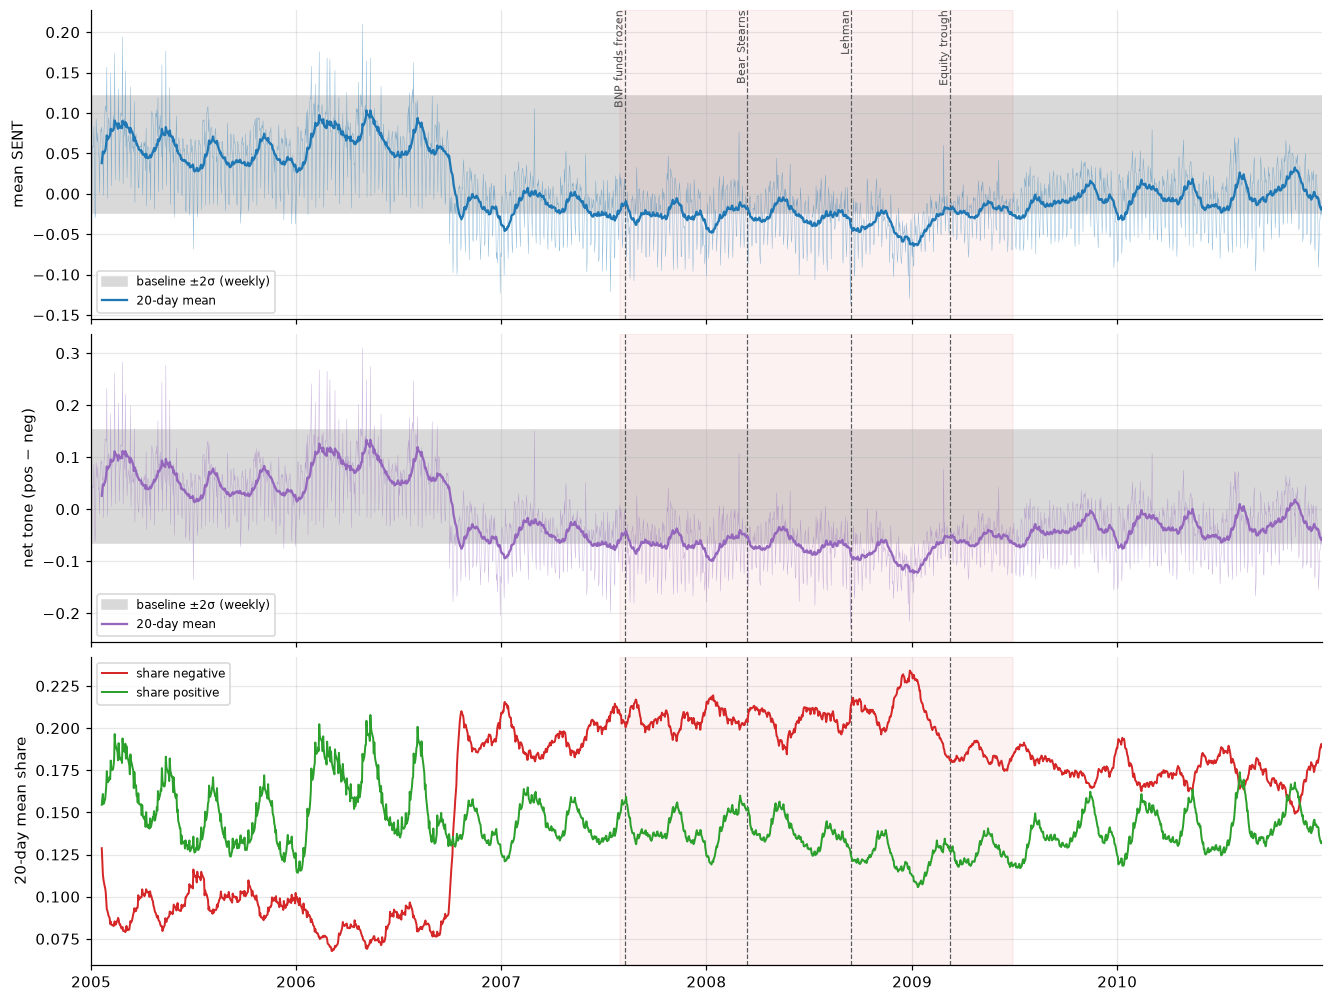

In [5]:
base_w = weekly.filter(pl.col("WEEK").is_between(*BASELINE))
roll = v.with_columns([pl.col(c).rolling_mean(ROLL).alias(f"R_{c}") for c in
                       ("MEAN_SENT", "NET_TONE", "SHARE_NEG", "SHARE_POS", "MEAN_CONF")])
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, col, label, color in ((axes[0], "MEAN_SENT", "mean SENT", "tab:blue"),
                              (axes[1], "NET_TONE", "net tone (pos − neg)", "tab:purple")):
    m, s = base_w[col].mean(), base_w[col].std()
    ax.axhspan(m - 2 * s, m + 2 * s, color="0.85", zorder=0, label="baseline ±2σ (weekly)")
    ax.plot(roll["DATE"], roll[col], lw=0.3, color=color, alpha=0.5)
    ax.plot(roll["DATE"], roll[f"R_{col}"], lw=1.5, color=color, label=f"{ROLL}-day mean")
    ax.set_ylabel(label); ax.legend(fontsize=8, loc="lower left")
axes[2].plot(roll["DATE"], roll["R_SHARE_NEG"], color="tab:red", lw=1.3, label="share negative")
axes[2].plot(roll["DATE"], roll["R_SHARE_POS"], color="tab:green", lw=1.3, label="share positive")
axes[2].set_ylabel(f"{ROLL}-day mean share"); axes[2].legend(fontsize=8, loc="upper left")
for ax in axes:
    date_axis(ax); shade_events(ax, labels=ax is axes[0])
plt.show()

## 3. Weekly z-scores and the event table

z = (weekly value − baseline mean) / baseline σ of the weekly series. For each event: the
value in the event's week, the change from the mean of the 4 previous weeks, and the most
negative z of net tone over the 6 following weeks.

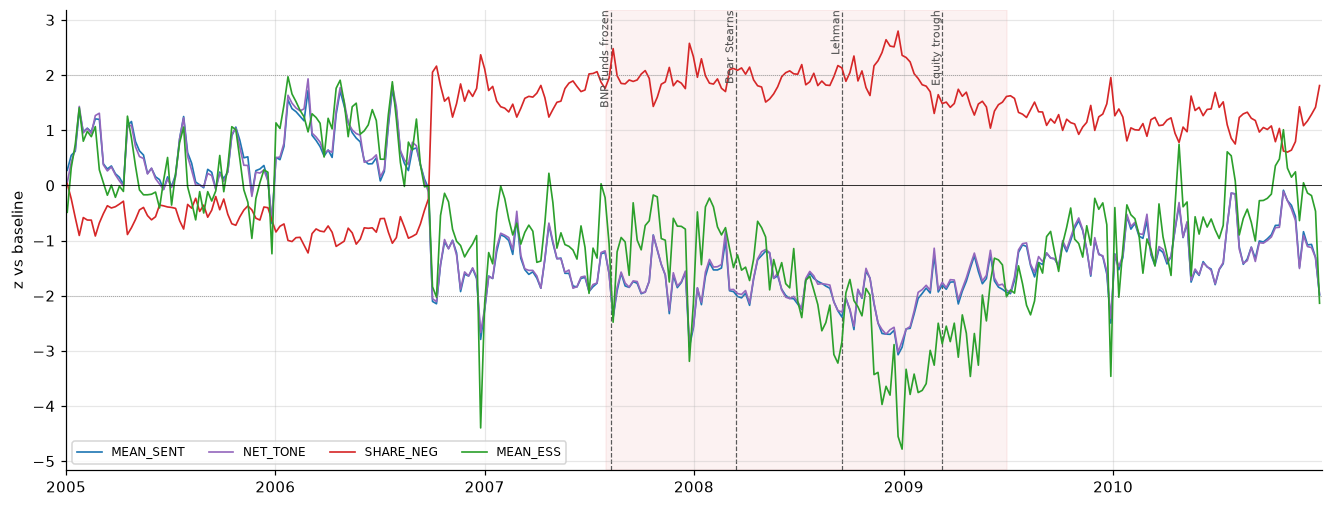

event,week,net_tone,Δ vs 4w before,z_net_tone,z_share_neg,min z_net_tone next 6w,z_ESS
str,date,f64,f64,f64,f64,f64,f64
"""BNP funds frozen""",2007-08-06,-0.044,-0.006,-1.602,1.947,-2.383,-1.061
"""Northern Rock""",2007-09-10,-0.057,0.003,-1.846,1.911,-1.95,-1.631
"""Bear Stearns""",2008-03-10,-0.059,-0.026,-1.886,2.119,-2.136,-1.491
"""GSE conservatorship""",2008-09-01,-0.072,-0.017,-2.115,1.973,-2.555,-3.066
"""Lehman""",2008-09-15,-0.082,-0.016,-2.297,2.129,-2.555,-2.839
"""TARP signed""",2008-09-29,-0.079,-0.003,-2.242,2.045,-2.555,-1.706
"""Coordinated cut""",2008-10-06,-0.096,-0.019,-2.555,2.346,-2.555,-2.089
"""NBER recession call""",2008-12-01,-0.104,-0.025,-2.697,2.641,-3.021,-3.643
"""Equity trough""",2009-03-09,-0.052,-0.004,-1.758,1.484,-2.072,-2.872


In [6]:
ZCOLS = ("MEAN_SENT", "NET_TONE", "SHARE_NEG", "MEAN_ESS")
stats = {c: (base_w[c].mean(), base_w[c].std()) for c in ZCOLS}
wz = weekly.with_columns([((pl.col(c) - stats[c][0]) / stats[c][1]).alias(f"Z_{c}") for c in ZCOLS])
wv = wz.filter(pl.col("WEEK").is_between(*VIEW))

fig, ax = plt.subplots(figsize=(12, 4.5))
for c, color in zip(ZCOLS, ("tab:blue", "tab:purple", "tab:red", "tab:green")):
    ax.plot(wv["WEEK"], wv[f"Z_{c}"], lw=1.1, color=color, label=c)
ax.axhline(0, color="k", lw=0.5)
for y in (-2, 2):
    ax.axhline(y, color="0.5", lw=0.5, ls=":")
ax.set_ylabel("z vs baseline"); ax.legend(fontsize=8, ncol=4, loc="lower left")
date_axis(ax); shade_events(ax)
plt.show()

weeks = wz["WEEK"].to_list()
rows = []
for ev, d in EVENTS.items():
    wk = d - timedelta(days=d.weekday())
    if wk not in weeks:
        continue
    i = weeks.index(wk)
    prior = wz[max(i - 4, 0):i]
    rows.append({"event": ev, "week": wk, "net_tone": wz["NET_TONE"][i],
                 "Δ vs 4w before": wz["NET_TONE"][i] - prior["NET_TONE"].mean(),
                 "z_net_tone": wz["Z_NET_TONE"][i], "z_share_neg": wz["Z_SHARE_NEG"][i],
                 "min z_net_tone next 6w": wz["Z_NET_TONE"][i:i + 7].min(),
                 "z_ESS": wz["Z_MEAN_ESS"][i]})
pl.DataFrame(rows).with_columns(pl.selectors.float().round(3))

## 4. Where the probability mass moves

Weekly mean predicted distribution minus the baseline mean distribution, per grid point
(red: more mass than usual). A shift of mass from the neutral middle to the negative tail is
what "more negative news" means for the model; a uniform level shift would not show here.

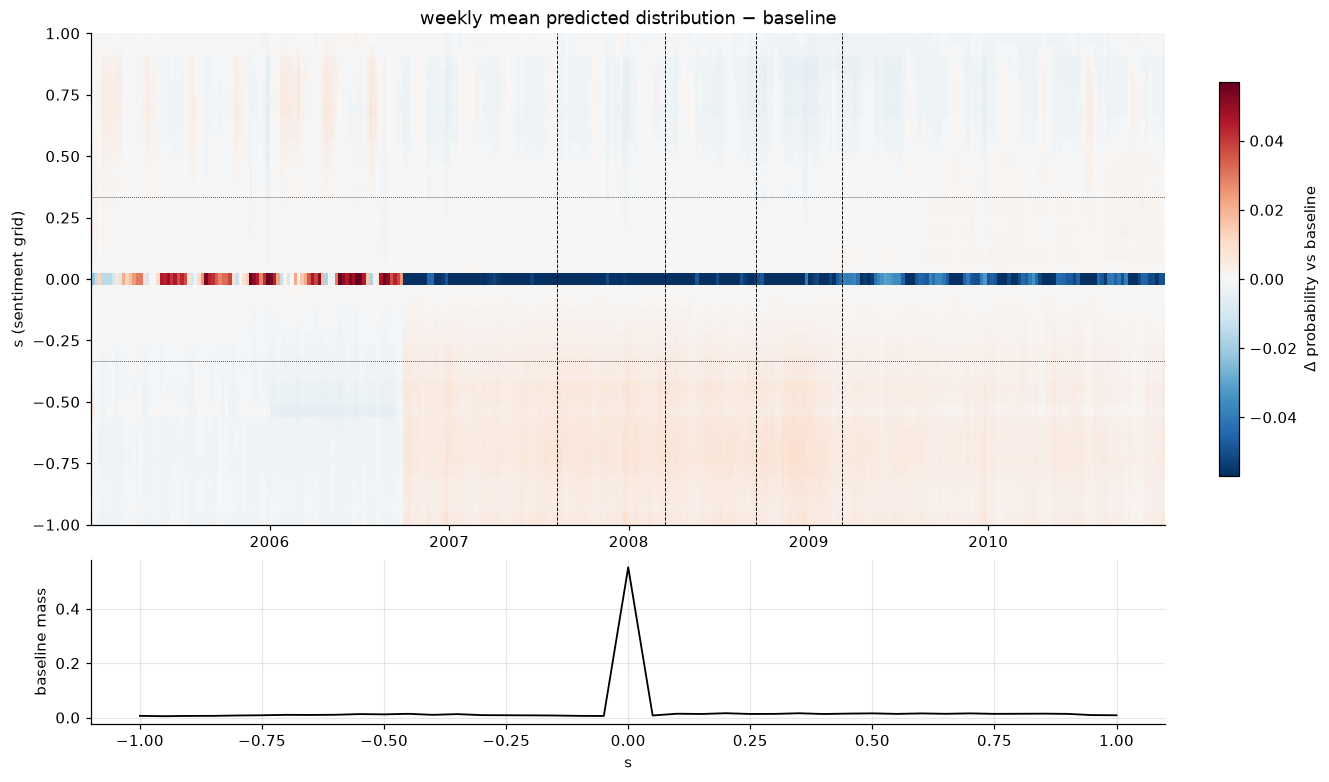

In [7]:
QCOLS = [f"Q_{j:02d}" for j in range(len(GRID))]
base_q = base_w.select(QCOLS).mean().to_numpy().ravel()
qv = weekly.filter(pl.col("WEEK").is_between(*VIEW))
diff = qv.select(QCOLS).to_numpy() - base_q
vmax = np.nanpercentile(np.abs(diff), 99)
x = mdates.date2num(qv["WEEK"].to_list())
fig, axes = plt.subplots(2, 1, figsize=(12, 7), height_ratios=[3, 1])
im = axes[0].imshow(diff.T, aspect="auto", origin="lower", cmap="RdBu_r",
                    norm=TwoSlopeNorm(0, -vmax, vmax), interpolation="nearest",
                    extent=[x[0], x[-1], GRID[0], GRID[-1]])
axes[0].xaxis_date(); axes[0].grid(False); axes[0].set_ylabel("s (sentiment grid)")
for y in (NEG_MAX, POS_MIN):
    axes[0].axhline(y, color="k", lw=0.5, ls=":")
for name in KEY_EVENTS:
    axes[0].axvline(EVENTS[name], color="k", lw=0.6, ls="--")
fig.colorbar(im, ax=axes[0], shrink=0.8, label="Δ probability vs baseline")
axes[0].set_title("weekly mean predicted distribution − baseline")
axes[1].plot(GRID, base_q, color="k", lw=1.2); axes[1].set_xlabel("s"); axes[1].set_ylabel("baseline mass")
plt.show()

## 5. By news type

The aggregate tone mixes news types with very different tones (press releases are positive,
full articles negative). A change in the mix moves the aggregate without any change in tone,
so the aggregate is compared with a **fixed-mix** tone: each type's weekly net tone weighted by
its baseline share.

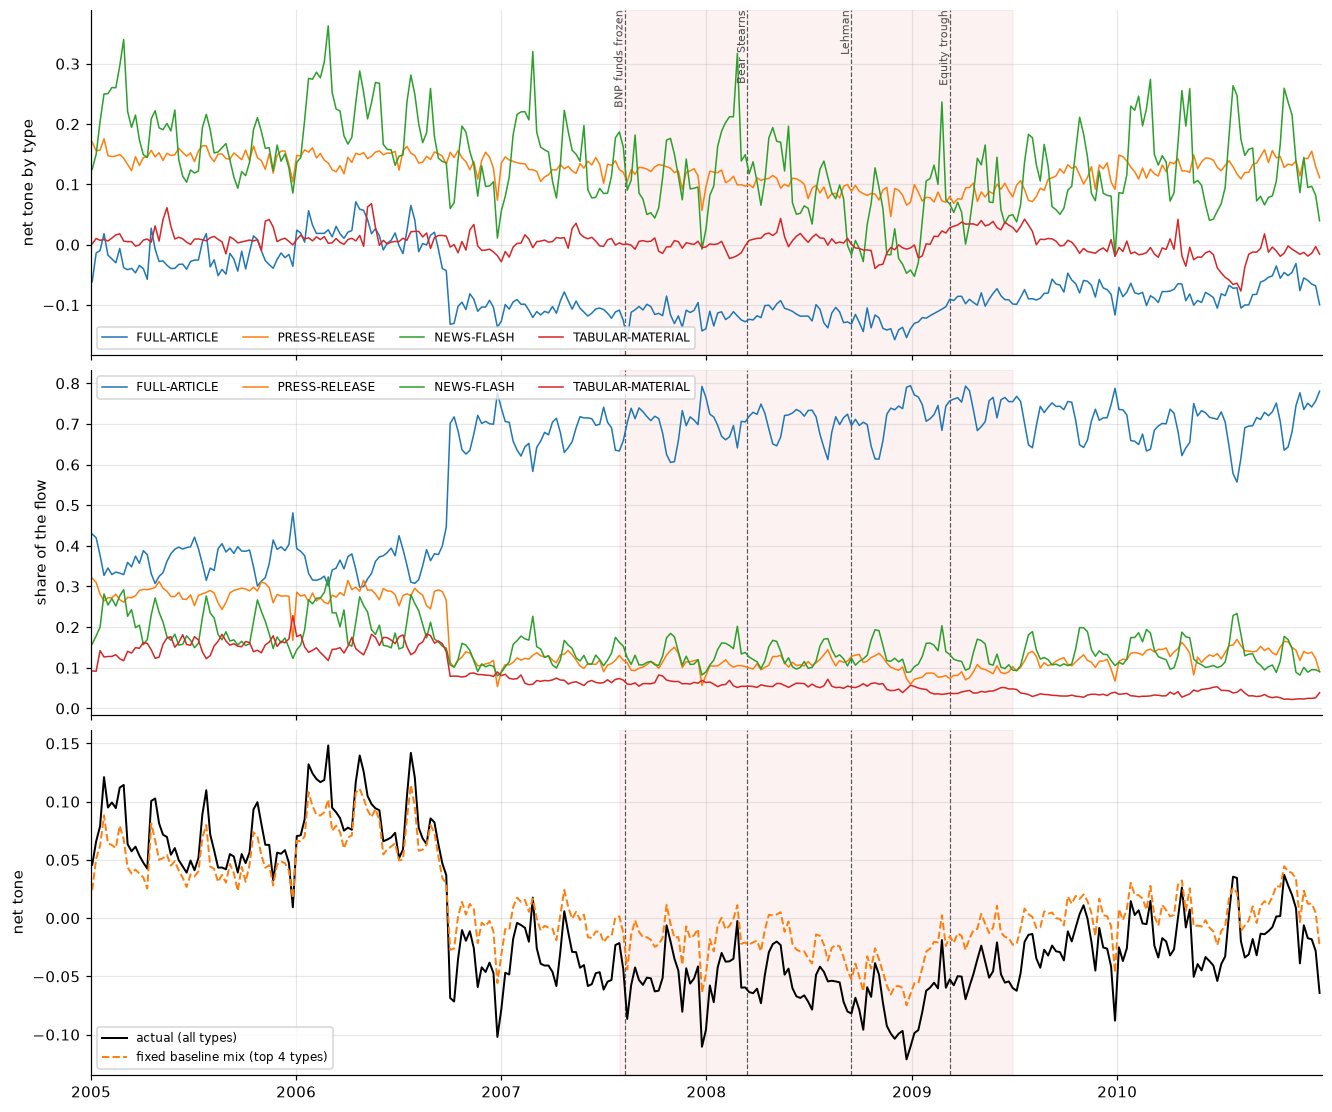

In [8]:
TYPES = (sums.filter(pl.col("DATE").is_between(*BASELINE)).group_by("NEWS_TYPE").agg(pl.col("N").sum())
         .sort("N", descending=True).head(4)["NEWS_TYPE"].to_list())
wt = summarise(sums.filter(pl.col("NEWS_TYPE").is_in(TYPES)), ["WEEK", "NEWS_TYPE"])
mix = (sums.filter(pl.col("DATE").is_between(*BASELINE) & pl.col("NEWS_TYPE").is_in(TYPES))
       .group_by("NEWS_TYPE").agg(pl.col("N").sum()).with_columns((pl.col("N") / pl.col("N").sum()).alias("W")))
fixed = (wt.join(mix.select("NEWS_TYPE", "W"), on="NEWS_TYPE")
         .group_by("WEEK").agg((pl.col("NET_TONE") * pl.col("W")).sum().alias("FIXED_MIX")).sort("WEEK"))
share = wt.with_columns((pl.col("N") / pl.col("N").sum().over("WEEK")).alias("SHARE"))

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for t in TYPES:
    g = wt.filter((pl.col("NEWS_TYPE") == t) & pl.col("WEEK").is_between(*VIEW))
    axes[0].plot(g["WEEK"], g["NET_TONE"], lw=1, label=t)
    s_ = share.filter((pl.col("NEWS_TYPE") == t) & pl.col("WEEK").is_between(*VIEW))
    axes[1].plot(s_["WEEK"], s_["SHARE"], lw=1, label=t)
axes[0].set_ylabel("net tone by type"); axes[0].legend(fontsize=8, ncol=4, loc="lower left")
axes[1].set_ylabel("share of the flow"); axes[1].legend(fontsize=8, ncol=4, loc="upper left")
fv = fixed.filter(pl.col("WEEK").is_between(*VIEW))
axes[2].plot(wv["WEEK"], wv["NET_TONE"], color="k", lw=1.3, label="actual (all types)")
axes[2].plot(fv["WEEK"], fv["FIXED_MIX"], color="tab:orange", lw=1.3, ls="--", label="fixed baseline mix (top 4 types)")
axes[2].set_ylabel("net tone"); axes[2].legend(fontsize=8, loc="lower left")
for ax in axes:
    date_axis(ax); shade_events(ax, labels=ax is axes[0])
plt.show()

## 6. RavenBERT vs RavenPack's own sentiment (ESS)

ESS is entity-level (event-based) and exists on ~30% of stories, so this compares two
different constructions on overlapping but different sets of headlines. Correlations on
weekly levels and weekly changes, and the cross-correlation of weekly changes (lag k > 0:
RavenBERT leads ESS by k weeks).

weekly corr(mean SENT, mean ESS): levels 0.858, changes 0.710  (313 weeks)


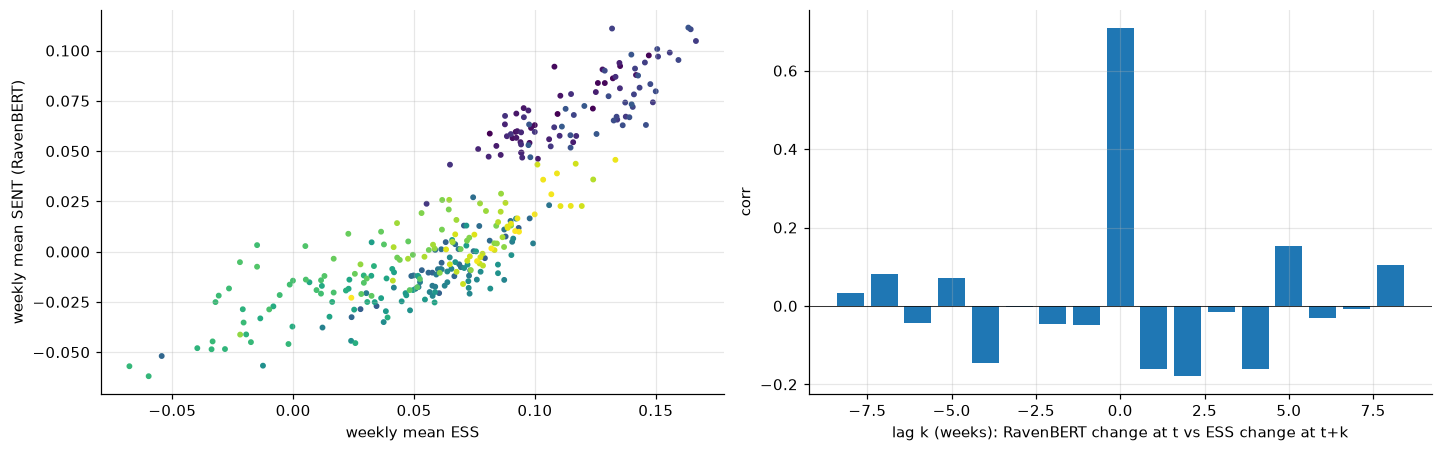

In [9]:
wb = wz.filter(pl.col("WEEK").is_between(*VIEW)).select("WEEK", "MEAN_SENT", "NET_TONE", "MEAN_ESS").drop_nulls()
lv = np.corrcoef(wb["MEAN_SENT"], wb["MEAN_ESS"])[0, 1]
ch = wb.select(pl.all().exclude("WEEK").diff()).drop_nulls()
dv = np.corrcoef(ch["MEAN_SENT"], ch["MEAN_ESS"])[0, 1]
print(f"weekly corr(mean SENT, mean ESS): levels {lv:.3f}, changes {dv:.3f}  ({wb.height} weeks)")

a, b = ch["MEAN_SENT"].to_numpy(), ch["MEAN_ESS"].to_numpy()
lags = range(-8, 9)
xc = [np.corrcoef(a[max(0, -k):len(a) - max(0, k)], b[max(0, k):len(b) - max(0, -k)])[0, 1] for k in lags]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(wb["MEAN_ESS"], wb["MEAN_SENT"], s=8, c=mdates.date2num(wb["WEEK"].to_list()), cmap="viridis")
axes[0].set_xlabel("weekly mean ESS"); axes[0].set_ylabel("weekly mean SENT (RavenBERT)")
axes[1].bar(list(lags), xc, color="tab:blue"); axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_xlabel("lag k (weeks): RavenBERT change at t vs ESS change at t+k"); axes[1].set_ylabel("corr")
plt.show()

## 7. Scoring-rule robustness

The bucket runs use the `mean` rule. `argmax` (the most likely class) and `median` summarise
the same distribution differently; a crisis signal that only one rule shows is fragile.

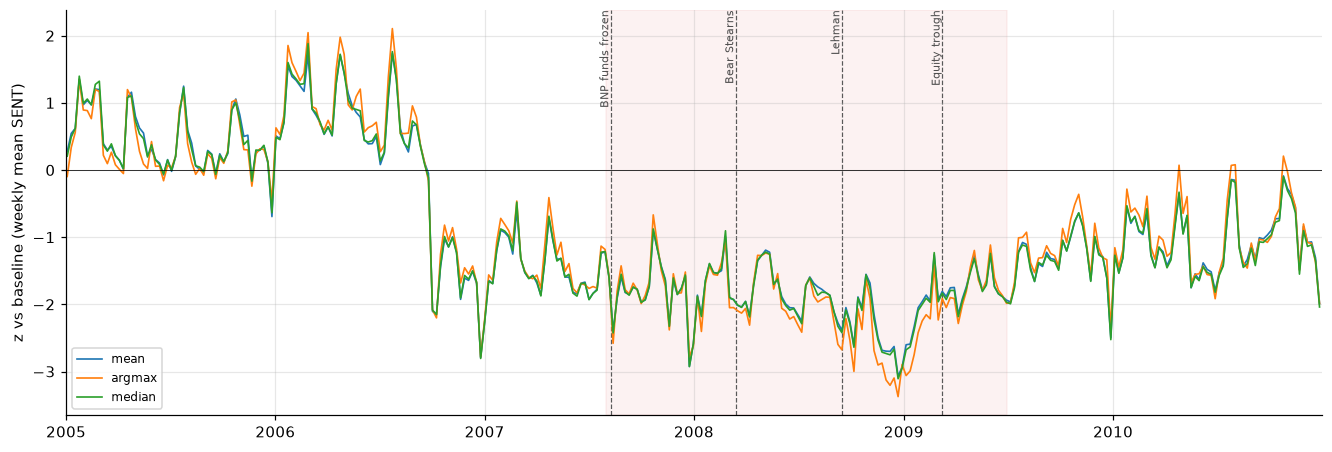

MEAN_SENT,MEAN_SENT_ARGMAX,MEAN_SENT_MEDIAN
f64,f64,f64
1.0,0.990424,0.999503
0.990424,1.0,0.992279
0.999503,0.992279,1.0


In [10]:
rv = weekly.filter(pl.col("WEEK").is_between(*VIEW))
rb = weekly.filter(pl.col("WEEK").is_between(*BASELINE))
fig, ax = plt.subplots(figsize=(12, 4))
for col, lab in (("MEAN_SENT", "mean"), ("MEAN_SENT_ARGMAX", "argmax"), ("MEAN_SENT_MEDIAN", "median")):
    z = (rv[col] - rb[col].mean()) / rb[col].std()
    ax.plot(rv["WEEK"], z, lw=1.1, label=lab)
ax.axhline(0, color="k", lw=0.5); ax.set_ylabel("z vs baseline (weekly mean SENT)")
ax.legend(fontsize=8, loc="lower left"); date_axis(ax); shade_events(ax)
plt.show()
rv.select("MEAN_SENT", "MEAN_SENT_ARGMAX", "MEAN_SENT_MEDIAN").corr()

## 8. Reading guide / caveats

* **All headlines, no narrative.** The tone here is the whole flow. A crisis can darken the
  tone of the narratives it touches while the rest of the flow is unchanged, and a change in
  what the flow talks about moves the aggregate even at constant tone per topic. The
  sentiment × narrative split (bucket runs of `narrative_daily`) separates the two.
* **Composition.** The feed's source and news-type mix changes over time; section 5 shows how
  much of the aggregate move survives a fixed mix. Weekends carry fewer, more negative headlines.
* **Headline-level model.** RavenBERT scores the headline text only; RavenPack's ESS is
  entity- and event-level and covers a subset of stories, so the two are not expected to agree
  day by day.
* **Point-in-time.** A headline's score depends only on its own text (a frozen model), so the
  series is available at each headline's timestamp; the baseline z-scores use a fixed
  pre-crisis window, i.e. they are descriptive, not a real-time signal.